shape: (301, 9)
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

any missing values?
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Selling_Price stats (in lakhs):
count    301.000000
mean       4.661296
std        5.082812
min        0.100000
25%        

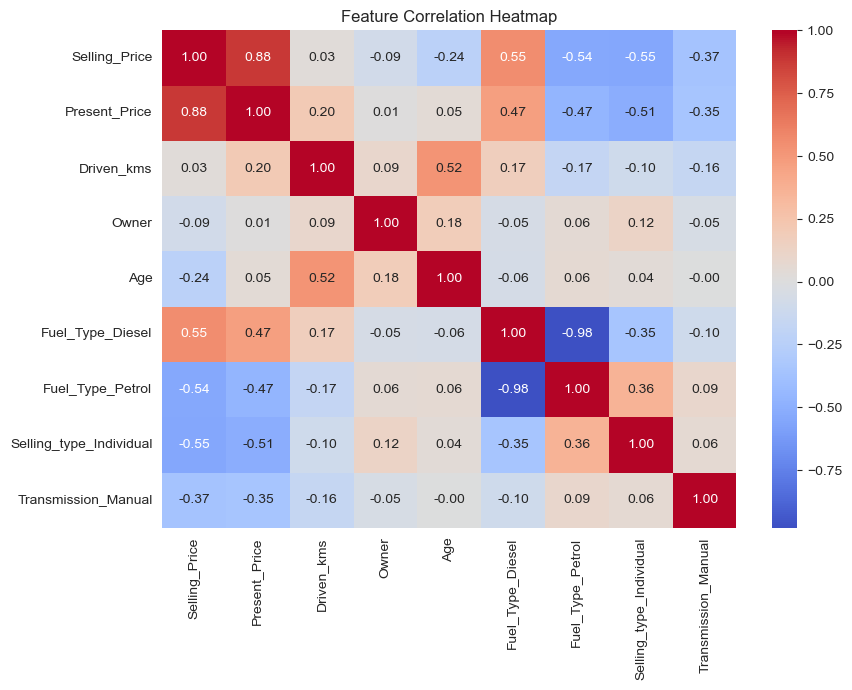

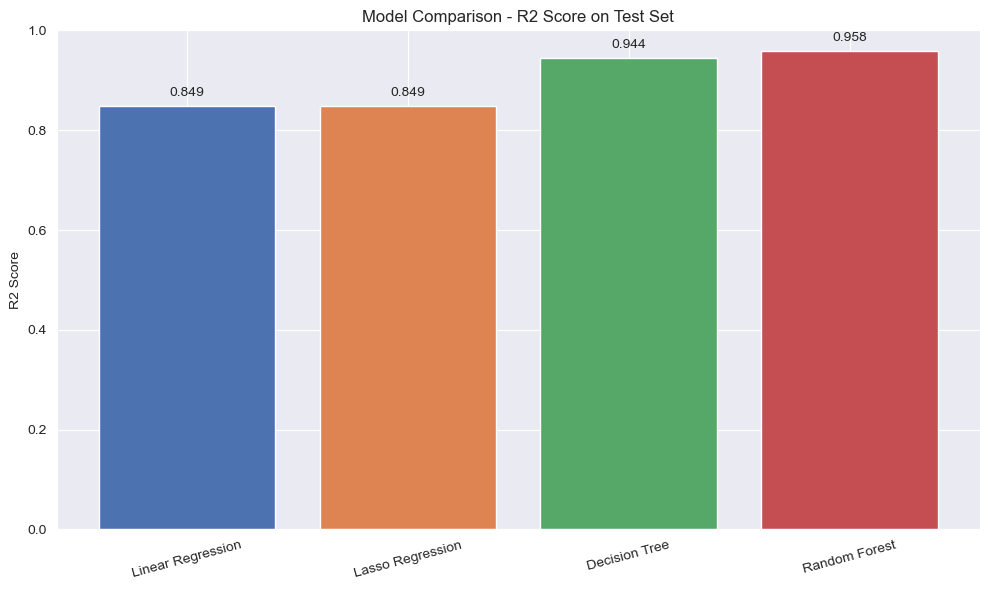

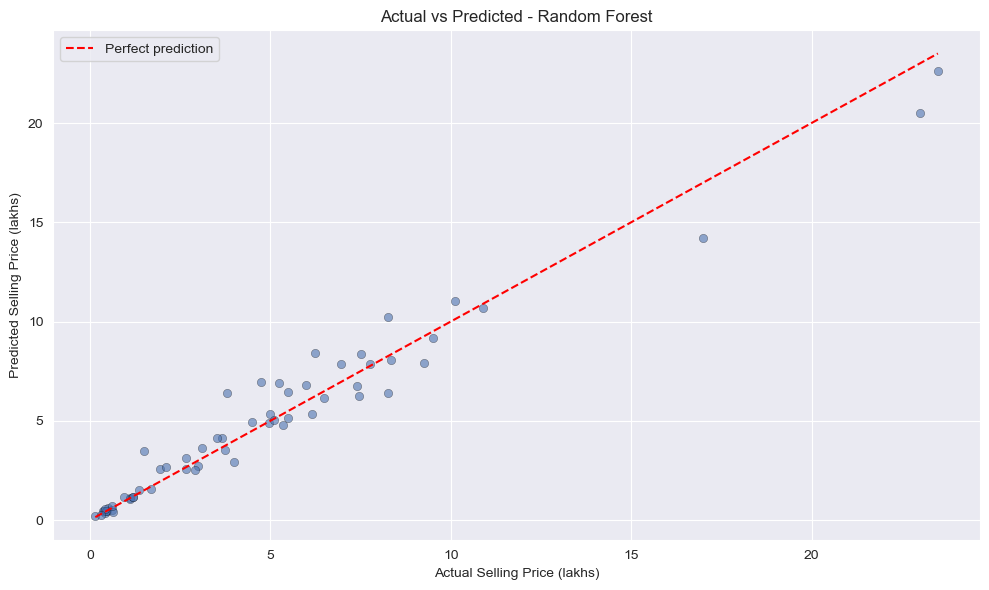

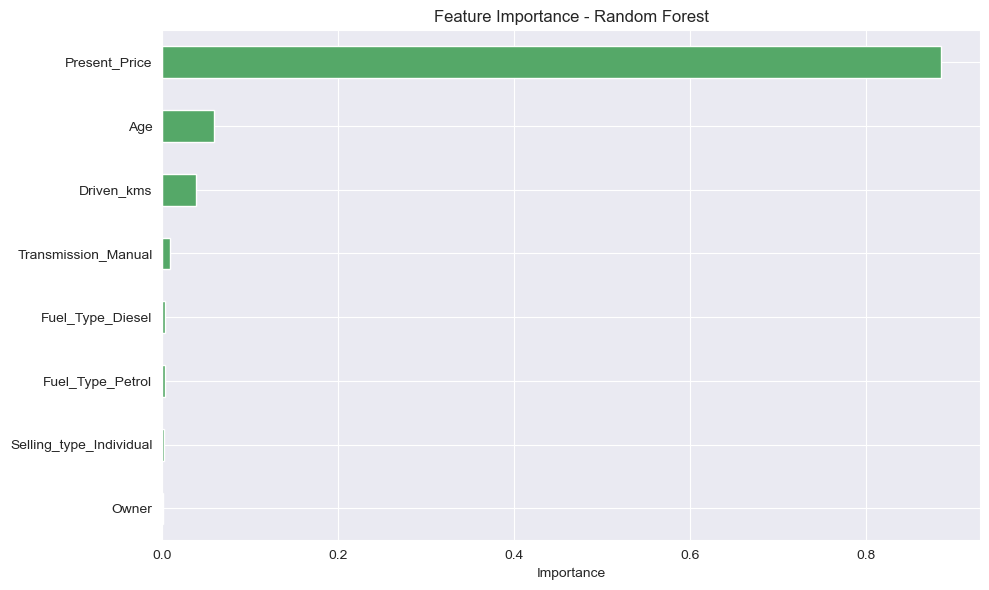

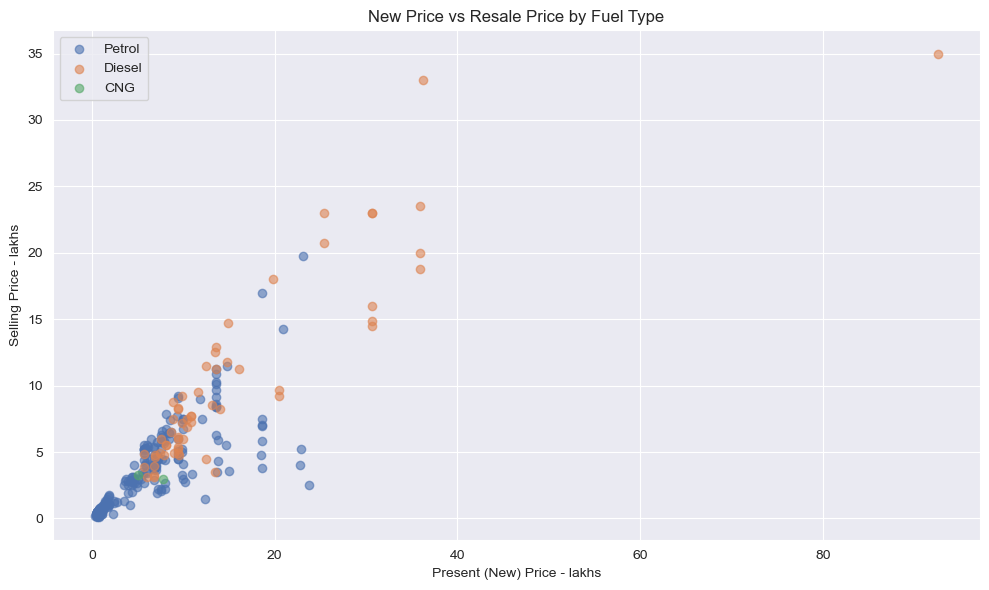

In [1]:
# Car Price Prediction
# Predicting the resale value of used cars based on their specs.
# Dataset has stuff like present (new) price, kms driven, fuel type, year etc.
# Selling_Price is what we're trying to predict (in lakhs)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42

# ---- load data ----
df = pd.read_csv("car data.csv")
print("shape:", df.shape)
print(df.head())
print("\nany missing values?")
print(df.isnull().sum())  # nope, dataset's already pretty clean

# ---- feature engineering ----
# a car's age matters way more to buyers than the actual year it was made,
# so let's convert Year into Age instead (dataset seems to be from 2020ish)
CURRENT_YEAR = 2020
df["Age"] = CURRENT_YEAR - df["Year"]
df = df.drop(columns=["Year"])

# Car_Name has ~100 unique values (specific models), too granular to be useful
# directly and would blow up one-hot encoding. Just drop it - the price info
# is already captured by Present_Price, fuel type, transmission etc.
df = df.drop(columns=["Car_Name"])

# quick sanity check on the target variable
print("\nSelling_Price stats (in lakhs):")
print(df["Selling_Price"].describe())

# ---- encode categoricals ----
# Fuel_Type, Selling_type and Transmission are all categorical text columns,
# need to turn these into numbers for the model. Going with one-hot since
# there's only a few categories in each (no ordinal relationship between them)
df_encoded = pd.get_dummies(df, columns=["Fuel_Type", "Selling_type", "Transmission"], drop_first=True)

print("\ncolumns after encoding:", df_encoded.columns.tolist())

# ---- correlation check ----
plt.figure(figsize=(9, 7))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()

# Present_Price is obviously going to be the strongest predictor - makes sense,
# a car that was expensive new is still going to sell for more used

# ---- train/test split ----
X = df_encoded.drop(columns=["Selling_Price"])
y = df_encoded["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"\ntrain size: {len(X_train)}, test size: {len(X_test)}")

# ---- try a few different regression models ----
models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=6),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=150),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results[name] = {"r2": r2, "mae": mae, "rmse": rmse, "preds": preds, "model": model}

    print(f"\n{name}")
    print(f"  R2 score : {r2:.4f}")
    print(f"  MAE      : {mae:.3f} lakhs")
    print(f"  RMSE     : {rmse:.3f} lakhs")

# pick the best one by R2
best_name = max(results, key=lambda k: results[k]["r2"])
best_model = results[best_name]["model"]
best_preds = results[best_name]["preds"]
print(f"\nbest model: {best_name} (R2 = {results[best_name]['r2']:.4f})")

# ---- feature importance (only makes sense for tree-based models) ----
if best_name in ("Random Forest", "Decision Tree"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("\nfeature importances:")
    print(importances)
else:
    # for linear models, look at the coefficients instead
    coefs = pd.Series(best_model.coef_, index=X.columns).sort_values(ascending=False)
    print("\nmodel coefficients:")
    print(coefs)


# 1. model comparison
fig, ax = plt.subplots()
names = list(results.keys())
r2_scores = [results[n]["r2"] for n in names]
bars = ax.bar(names, r2_scores, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
ax.set_ylabel("R2 Score")
ax.set_title("Model Comparison - R2 Score on Test Set")
ax.set_ylim(0, 1)
for bar, score in zip(bars, r2_scores):
    ax.text(bar.get_x() + bar.get_width()/2, score + 0.02, f"{score:.3f}", ha="center")
plt.xticks(rotation=15)
plt.tight_layout()


# 2. actual vs predicted for the best model
fig, ax = plt.subplots()
ax.scatter(y_test, best_preds, alpha=0.6, color="#4C72B0", edgecolor="k", linewidth=0.3)
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
ax.plot(lims, lims, "r--", label="Perfect prediction")
ax.set_xlabel("Actual Selling Price (lakhs)")
ax.set_ylabel("Predicted Selling Price (lakhs)")
ax.set_title(f"Actual vs Predicted - {best_name}")
ax.legend()
plt.tight_layout()


# 3. feature importance chart (if tree model won)
if best_name in ("Random Forest", "Decision Tree"):
    fig, ax = plt.subplots()
    importances.plot(kind="barh", ax=ax, color="#55A868")
    ax.set_xlabel("Importance")
    ax.set_title(f"Feature Importance - {best_name}")
    ax.invert_yaxis()
    plt.tight_layout()
    

# 4. present price vs selling price, colored by fuel type (sanity check plot)
fig, ax = plt.subplots()
for fuel, color in zip(df["Fuel_Type"].unique(), ["#4C72B0", "#DD8452", "#55A868"]):
    subset = df[df["Fuel_Type"] == fuel]
    ax.scatter(subset["Present_Price"], subset["Selling_Price"], label=fuel, alpha=0.6, color=color)
ax.set_xlabel("Present (New) Price - lakhs")
ax.set_ylabel("Selling Price - lakhs")
ax.set_title("New Price vs Resale Price by Fuel Type")
ax.legend()
plt.tight_layout()
